In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

In [31]:
DT = 0.05
INPUT_LEN = 4000
HORIZON = 1000

train_noisy = pd.read_csv('train.csv', header=None).values.astype(np.float32)
test_noisy = pd.read_csv('test.csv', header=None).values.astype(np.float32)
train_clean_full = pd.read_csv('etalon_for_train.csv', header=None).values.astype(np.float32)
test_clean_full = pd.read_csv('etalon_for_test.csv', header=None).values.astype(np.float32)

X_train_noisy = train_noisy[:, :INPUT_LEN]
X_test_noisy = test_noisy[:, :INPUT_LEN]

X_train_clean = train_clean_full[:, :INPUT_LEN]
X_test_clean = test_clean_full[:, :INPUT_LEN]

y_train_clean = train_clean_full[:, INPUT_LEN:INPUT_LEN + HORIZON]
y_test_clean = test_clean_full[:, INPUT_LEN:INPUT_LEN + HORIZON]

print('Обучающая выборка (зашумлённая):', X_train_noisy.shape)
print('Обучающая выборка (чистая, прошлое):', X_train_clean.shape)
print('Обучающая выборка (чистая, будущее):', y_train_clean.shape)
print('Тестовая выборка (зашумлённая):', X_test_noisy.shape)
print('Тестовая выборка (чистая, будущее):', y_test_clean.shape)

Обучающая выборка (зашумлённая): (1000, 4000)
Обучающая выборка (чистая, прошлое): (1000, 4000)
Обучающая выборка (чистая, будущее): (1000, 1000)
Тестовая выборка (зашумлённая): (500, 4000)
Тестовая выборка (чистая, будущее): (500, 1000)


In [17]:
def denoise_batch(data_2d: np.ndarray, window_length: int, polyorder: int = 3) -> np.ndarray:
    return savgol_filter(data_2d, window_length=window_length, polyorder=polyorder, axis=1).astype(np.float32)

candidate_windows = [11, 21, 31, 41, 61, 81]
best_window = None
best_mse = np.inf

for w in candidate_windows:
    den = denoise_batch(X_train_noisy, window_length=w, polyorder=3)
    mse = mean_squared_error(X_train_clean.reshape(-1), den.reshape(-1))
    if mse < best_mse:
        best_mse = mse
        best_window = w

X_train_denoised = denoise_batch(X_train_noisy, window_length=best_window, polyorder=3)
X_test_denoised = denoise_batch(X_test_noisy, window_length=best_window, polyorder=3)

print(f'Лучшее окно сглаживания: {best_window}')
print(f'MSE сглаживания на обучающей выборке: {best_mse:.6f}')

Лучшее окно сглаживания: 81
MSE сглаживания на обучающей выборке: 0.009431


In [19]:
def extract_features(series_2d: np.ndarray, n_fft: int = 128, downsample_step: int = 40) -> np.ndarray:
    fft_amp = np.abs(np.fft.rfft(series_2d, axis=1))[:, 1:n_fft + 1]
    ds = series_2d[:, ::downsample_step]
    mean_ = series_2d.mean(axis=1, keepdims=True)
    std_ = series_2d.std(axis=1, keepdims=True)
    slope_ = (series_2d[:, -1] - series_2d[:, 0]).reshape(-1, 1)
    return np.hstack([fft_amp, ds, mean_, std_, slope_]).astype(np.float32)

X_train_feat = extract_features(X_train_denoised)
X_test_feat = extract_features(X_test_denoised)

print('Матрица признаков (обучение):', X_train_feat.shape)
print('Матрица признаков (тест):', X_test_feat.shape)

Матрица признаков (обучение): (1000, 231)
Матрица признаков (тест): (500, 231)


In [20]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=7, weights='distance', metric='euclidean', n_jobs=-1)),
])

model.fit(X_train_feat, y_train_clean)
y_pred = model.predict(X_test_feat).astype(np.float32)

print('Размер прогноза:', y_pred.shape)

Размер прогноза: (500, 1000)


In [21]:
# Базовый прогноз 1: перенос последнего наблюденного значения
last_points = X_test_noisy[:, -1].reshape(-1, 1)
naive_point = np.repeat(last_points, HORIZON, axis=1).astype(np.float32)

# Базовый прогноз 2: среднее по последним 1000 наблюдениям
past_mean = X_test_noisy[:, -1000:].mean(axis=1, keepdims=True)
mean_baseline = np.repeat(past_mean, HORIZON, axis=1).astype(np.float32)

errors = y_pred - y_test_clean
errors_naive = naive_point - y_test_clean
errors_mean = mean_baseline - y_test_clean

# Обязательные метрики
mean_error_per_step = errors.mean(axis=0)
rmse_per_step = np.sqrt((errors ** 2).mean(axis=0))

# Дополнительные метрики для полного сравнения с готовым примером
rmse_naive_per_step = np.sqrt((errors_naive ** 2).mean(axis=0))
rmse_mean_per_step = np.sqrt((errors_mean ** 2).mean(axis=0))

mse_denoise = mean_squared_error(X_test_clean.reshape(-1), X_test_denoised.reshape(-1))
mse_model = mean_squared_error(y_test_clean.reshape(-1), y_pred.reshape(-1))
mse_naive = mean_squared_error(y_test_clean.reshape(-1), naive_point.reshape(-1))
mse_mean = mean_squared_error(y_test_clean.reshape(-1), mean_baseline.reshape(-1))
rmse_total = np.sqrt(mse_model)
mae_total = mean_absolute_error(y_test_clean.reshape(-1), y_pred.reshape(-1))

print('=== Метрики на тесте (модель + базовые прогнозы) ===')
print(f'MSE сглаживания (прошлая часть): {mse_denoise:.6f}')
print(f'MSE прогноза модели:          {mse_model:.6f}')
print(f'MSE наивного точечного:       {mse_naive:.6f}')
print(f'MSE baseline по среднему:     {mse_mean:.6f}')
print(f'RMSE прогноза модели:         {rmse_total:.6f}')
print(f'MAE прогноза модели:          {mae_total:.6f}')
print(f'RMSE h=1:                     {rmse_per_step[0]:.6f}')
print(f'RMSE h={HORIZON}:                  {rmse_per_step[-1]:.6f}')

=== Метрики на тесте (модель + базовые прогнозы) ===
MSE сглаживания (прошлая часть): 0.009453
MSE прогноза модели:          0.295275
MSE наивного точечного:       0.841165
MSE baseline по среднему:     0.274066
RMSE прогноза модели:         0.543392
MAE прогноза модели:          0.434574
RMSE h=1:                     0.474916
RMSE h=1000:                  0.562676


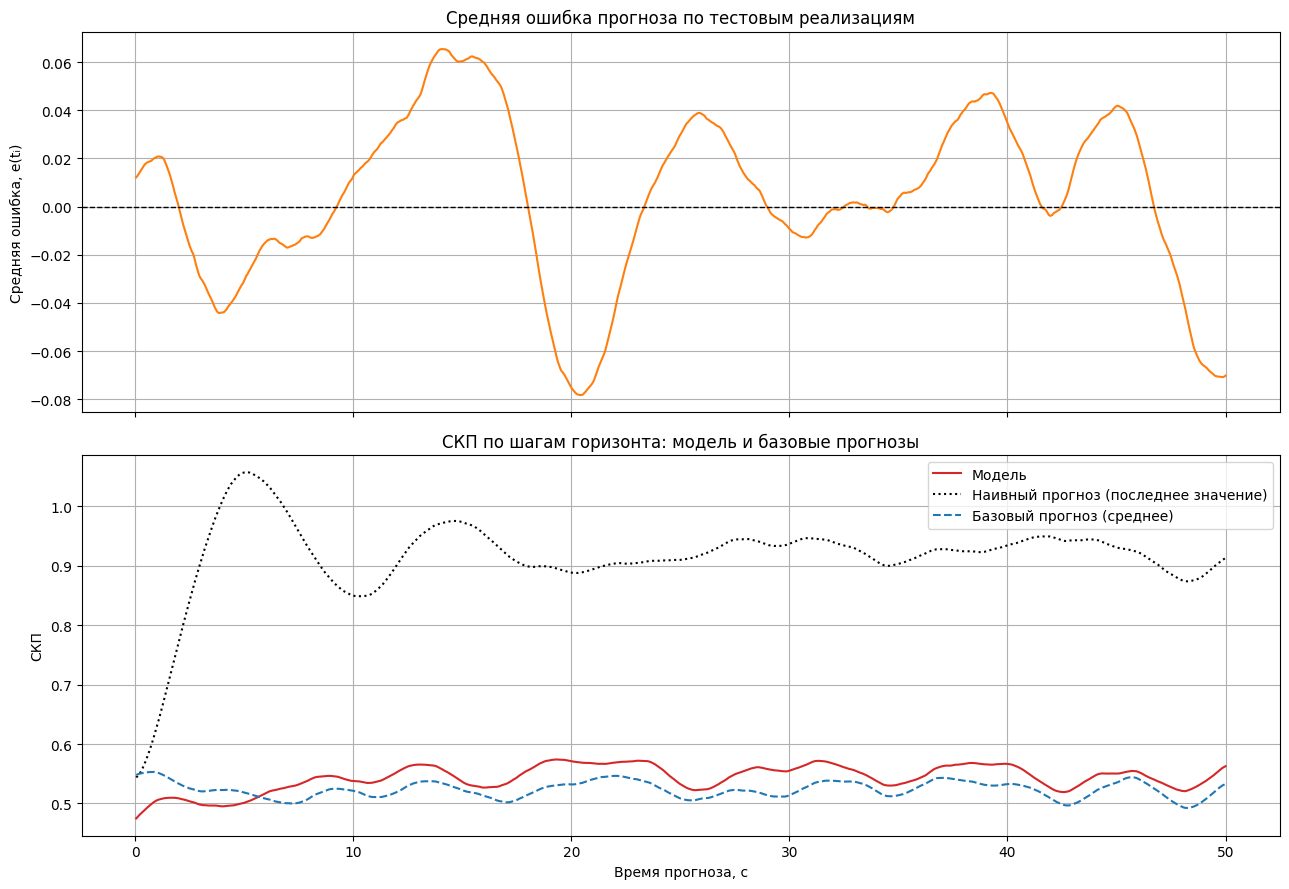

In [24]:
h = np.arange(1, HORIZON + 1)
time_future = h * DT

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

axes[0].plot(time_future, mean_error_per_step, color='tab:orange')
axes[0].axhline(0.0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Средняя ошибка прогноза по тестовым реализациям')
axes[0].set_ylabel('Средняя ошибка, e(tᵢ)')

axes[1].plot(time_future, rmse_per_step, color='tab:red', label='Модель')
axes[1].plot(time_future, rmse_naive_per_step, color='black', linestyle=':', label='Наивный прогноз (последнее значение)')
axes[1].plot(time_future, rmse_mean_per_step, color='tab:blue', linestyle='--', label='Базовый прогноз (среднее)')
axes[1].set_title('СКП по шагам горизонта: модель и базовые прогнозы')
axes[1].set_xlabel('Время прогноза, с')
axes[1].set_ylabel('СКП')
axes[1].legend()

plt.tight_layout()
plt.show()

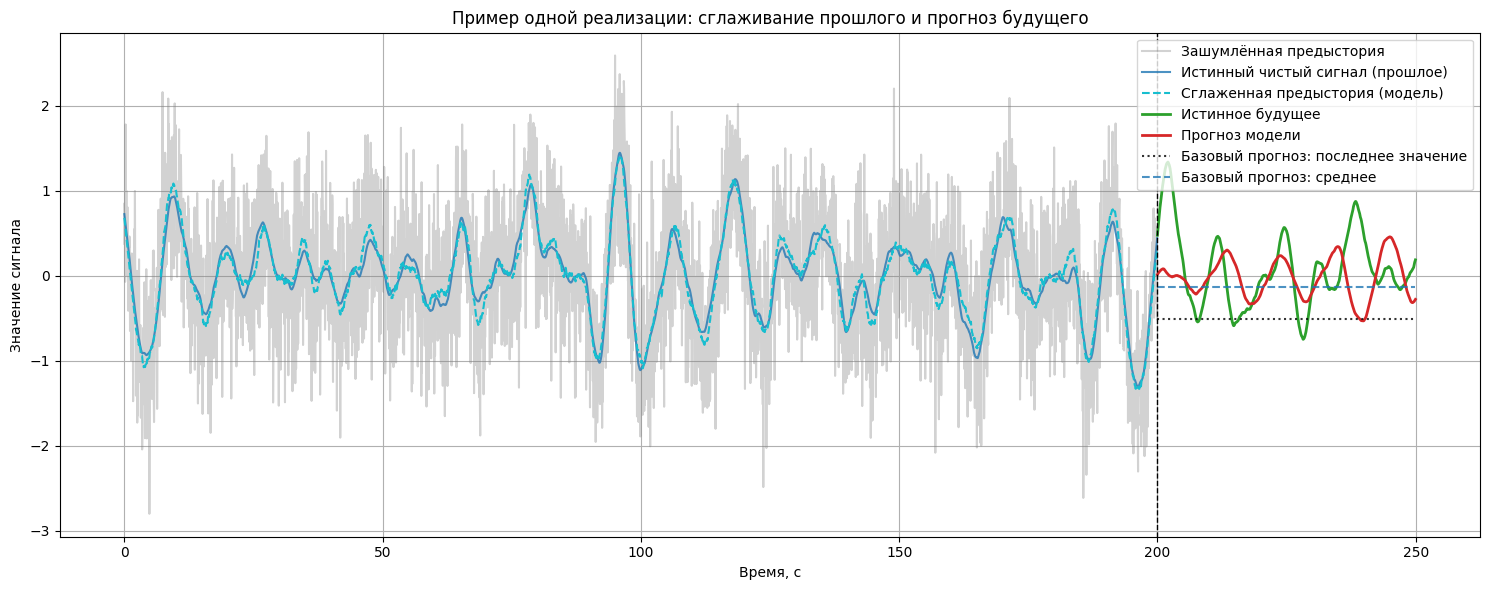

In [26]:
idx = 0
past_t = np.arange(INPUT_LEN) * DT
future_t = np.arange(INPUT_LEN, INPUT_LEN + HORIZON) * DT

plt.figure(figsize=(15, 6))
plt.plot(past_t, X_test_noisy[idx], color='gray', alpha=0.35, label='Зашумлённая предыстория')
plt.plot(past_t, X_test_clean[idx], color='tab:blue', alpha=0.8, label='Истинный чистый сигнал (прошлое)')
plt.plot(past_t, X_test_denoised[idx], color='tab:cyan', linestyle='--', label='Сглаженная предыстория (модель)')

plt.plot(future_t, y_test_clean[idx], color='tab:green', linewidth=2, label='Истинное будущее')
plt.plot(future_t, y_pred[idx], color='tab:red', linewidth=2, label='Прогноз модели')
plt.plot(future_t, naive_point[idx], color='black', linestyle=':', alpha=0.8, label='Базовый прогноз: последнее значение')
plt.plot(future_t, mean_baseline[idx], color='tab:blue', linestyle='--', alpha=0.8, label='Базовый прогноз: среднее')

plt.axvline(INPUT_LEN * DT, color='black', linestyle='--', linewidth=1)
plt.title('Пример одной реализации: сглаживание прошлого и прогноз будущего')
plt.xlabel('Время, с')
plt.ylabel('Значение сигнала')
plt.legend()
plt.tight_layout()
plt.show()

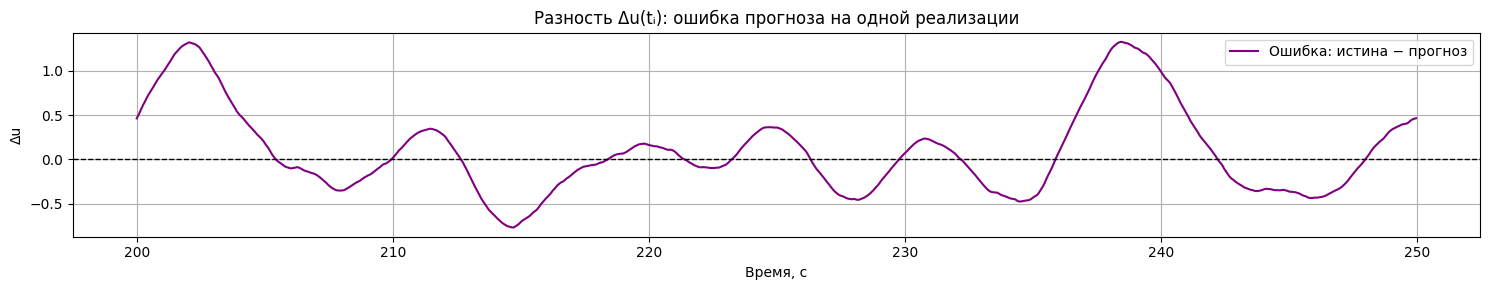

In [27]:
idx = 0
delta_u = y_test_clean[idx] - y_pred[idx]

plt.figure(figsize=(15, 3))
plt.plot(future_t, delta_u, color='purple', label='Ошибка: истина − прогноз')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Разность Δu(tᵢ): ошибка прогноза на одной реализации')
plt.xlabel('Время, с')
plt.ylabel('Δu')
plt.legend()
plt.tight_layout()
plt.show()

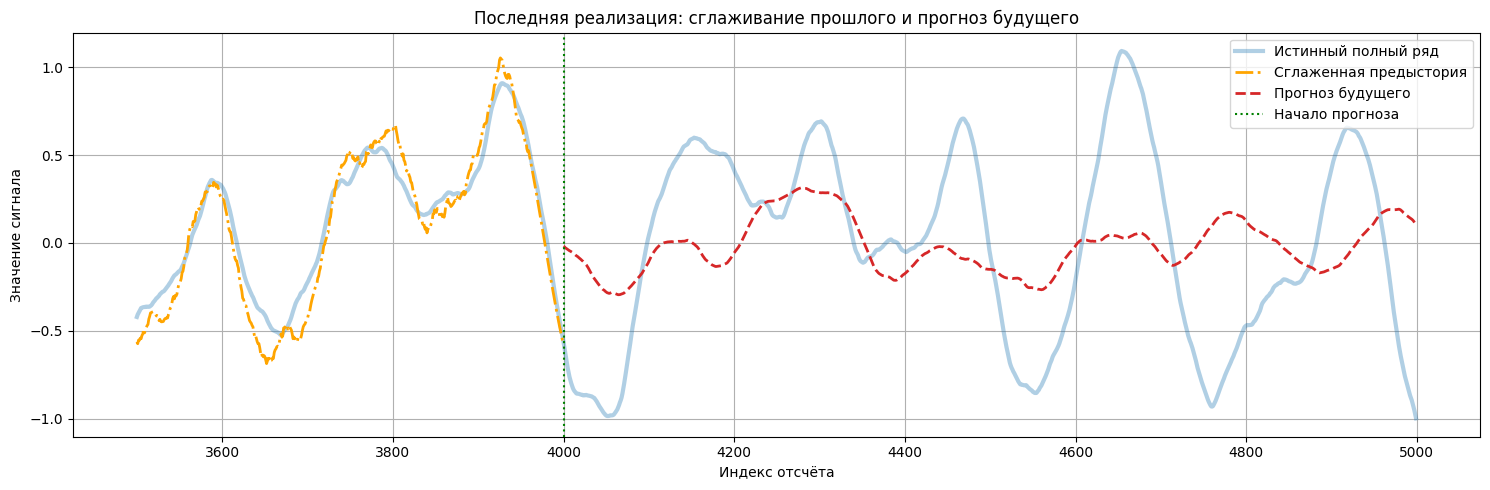

СКП на шаге h=1:      0.474916
СКП на шаге h=1000: 0.562676


In [29]:
steps_to_generate = HORIZON
seed_len = INPUT_LEN
total_len = INPUT_LEN + HORIZON

view_count = 1500
start_view = total_len - view_count
indices = np.arange(start_view, total_len)

idx_to_plot = -1
last_sample_true = test_clean_full[idx_to_plot]
last_preds_future = y_pred[idx_to_plot]
last_preds_past = X_test_denoised[idx_to_plot]

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(indices, last_sample_true[start_view:], color='tab:blue', alpha=0.35, lw=3,
        label='Истинный полный ряд')
ax.plot(np.arange(start_view, seed_len), last_preds_past[start_view:], color='orange',
        linestyle='-.', lw=2, label='Сглаженная предыстория')
ax.plot(np.arange(seed_len, total_len), last_preds_future, color='tab:red',
        linestyle='--', lw=2, label='Прогноз будущего')
ax.axvline(x=seed_len, color='green', linestyle=':', label='Начало прогноза')
ax.set_title('Последняя реализация: сглаживание прошлого и прогноз будущего')
ax.set_xlabel('Индекс отсчёта')
ax.set_ylabel('Значение сигнала')
ax.legend()
plt.tight_layout()
plt.show()

print(f'СКП на шаге h=1:      {rmse_per_step[0]:.6f}')
print(f'СКП на шаге h={steps_to_generate}: {rmse_per_step[-1]:.6f}')

**Работа по шагам:**

1. Предобработка и сглаживание входного ряда;
2. Формирование признаков для модели;
3. Обучение модели прогноза;
4. Расчет метрик качества и сравнение с базовыми решениями;
5. Визуальный анализ ошибок, СКП по шагам и поведения на горизонте.